In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

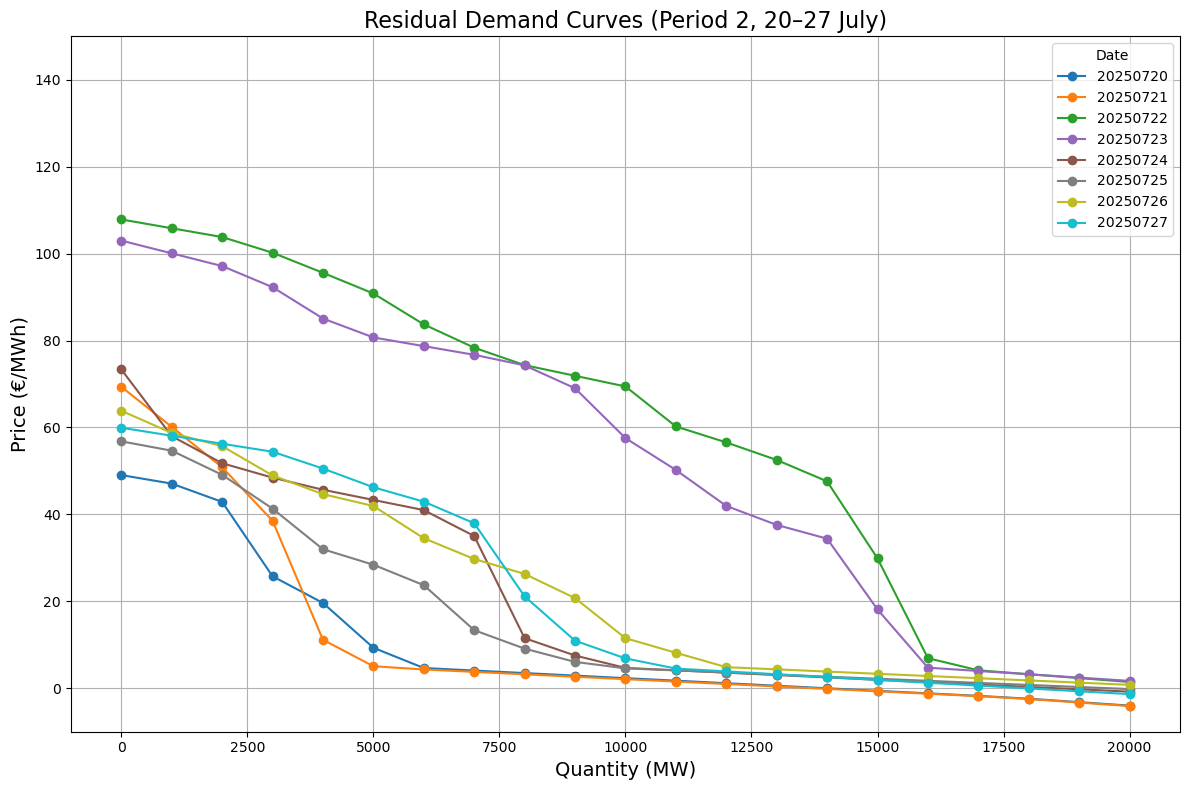

In [6]:
# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i],     price_grid[i+1]
            r0, r1 = resid[i],          resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- B) 공통 설정 ---
period       = 2
days         = range(20, 28)   # 20~27일
n_rdc_points = 30

# --- C) stepwise 설정
qini            = {}
qmax            = {}
lambda_da_block = {}
B = 10  # 원하시는 블록 개수로 조정하세요

# 컬러맵
colors = plt.cm.tab10(np.linspace(0,1,len(days)))

plt.figure(figsize=(12,8))

for day, color in zip(days, colors):
    date_str = f"202507{day:02d}"
    fn       = f"filteredcurve_{date_str}.csv"
    try:
        df = pd.read_csv(fn, encoding='utf-8-sig')
    except FileNotFoundError:
        print(f"⚠ 파일 없음: {fn}")
        continue

    # Price/Amount 이미 float라 가정
    # Period 필터
    sub    = df[df['Time Period'] == period]
    supply = sub[sub['GC'] == 'V']
    demand = sub[sub['GC'] == 'C']
    if supply.empty or demand.empty:
        print(f"⚠ 데이터 부족: {date_str}")
        continue

    # 공급/수요 집계
    s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
    s_agg['CumulQty'] = s_agg['Amount'].cumsum()
    d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
    d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

    # 계단형 보간
    supply_func = interp1d(s_agg['Price'],    s_agg['CumulQty'],
                           kind='previous', bounds_error=False,
                           fill_value=(0, s_agg['CumulQty'].iat[-1]))
    demand_func = interp1d(d_agg['Price'],    d_agg['CumulQty'],
                           kind='previous', bounds_error=False,
                           fill_value=(d_agg['CumulQty'].iat[0], 0))

    price_grid   = np.linspace(
        min(s_agg['Price'].min(), d_agg['Price'].min()),
        max(s_agg['Price'].max(), d_agg['Price'].max()),
        500
    )
    supply_vals  = supply_func(price_grid)
    demand_vals  = demand_func(price_grid)
    # 풍력 입찰량 격자: 0, 100, 200, …, 50000
    wf_offer_grid = np.arange(0, 20001, 1000)
    rdc_pts = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offer_grid)
    q_vals, p_vals = zip(*rdc_pts)

    # ——— 여기에 stepwise 근사 파라미터 계산 추가 —————————
    qv = np.array(q_vals)
    pv = np.array(p_vals)
    t  = day  # 또는 원하는 시간 인덱스로 사용

    if qv.size > 0:
        q_breaks   = np.linspace(0, qv.max(), B+1)
        delta_qs   = q_breaks[1:] - q_breaks[:-1]
        for b in range(B):
            mid = 0.5*(q_breaks[b] + q_breaks[b+1])
            qini[(t,b)]            = float(q_breaks[b])
            qmax[(t,b)]            = float(delta_qs[b])
            lambda_da_block[(t,b)] = float(np.interp(mid, qv, pv))
    else:
        for b in range(B):
            qini[(t,b)]            = 0.0
            qmax[(t,b)]            = 0.0
            lambda_da_block[(t,b)] = 0.0
    # ——————————————————————————————————————————————

    # 이제 Residual Demand Curve만 그립니다
    plt.plot(q_vals, p_vals, 'o-', color=color, label=date_str)

# --- C) 그래프 꾸미기 ---
plt.xlabel('Quantity (MW)', fontsize=14)
plt.ylabel('Price (€/MWh)', fontsize=14)
plt.ylim(-10,150)
plt.title(f'Residual Demand Curves (Period {period}, 20–27 July)', fontsize=16)
plt.legend(title='Date', loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


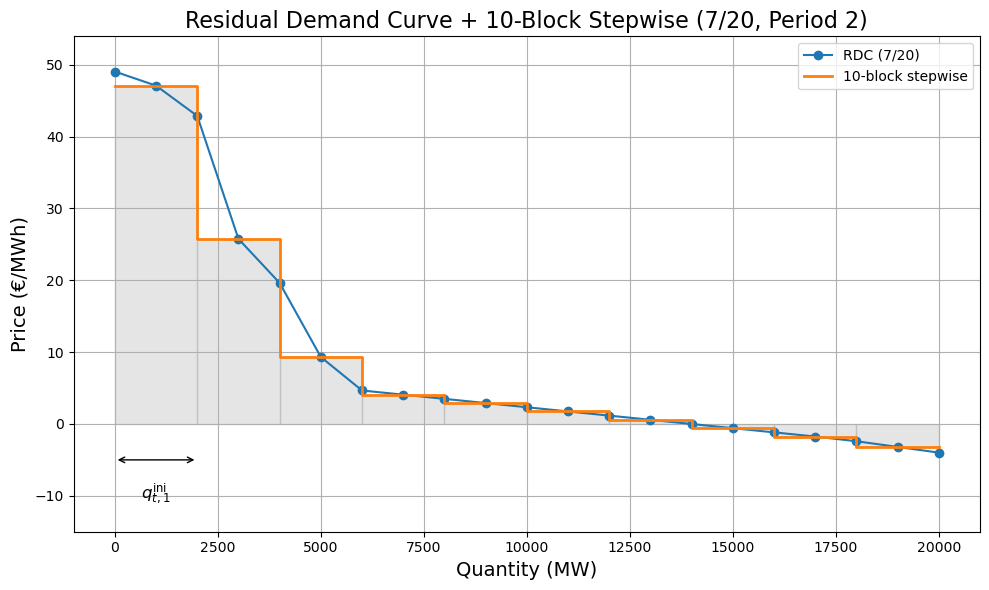

In [7]:


# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i],     price_grid[i+1]
            r0, r1 = resid[i],          resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- 1) 파라미터 설정 ---
period        = 2
date_str      = "20250720"         # 7월 20일
fn            = f"filteredcurve_{date_str}.csv"
B             = 10                 # 블록 수
wf_offer_grid = np.arange(0, 20001, 1000)

# --- 2) 데이터 읽기 & 전처리 ---
df = pd.read_csv(fn, encoding='utf-8-sig')
sub    = df[df['Time Period']==period]
supply = sub[sub['GC']=='V']
demand = sub[sub['GC']=='C']
if supply.empty or demand.empty:
    raise ValueError(f"{date_str}에 period={period} 데이터가 없습니다.")

# 공급/수요 누적 집계
s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
s_agg['CumulQty'] = s_agg['Amount'].cumsum()
d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

# 계단형 보간 함수
supply_func = interp1d(
    s_agg['Price'], s_agg['CumulQty'],
    kind='previous', bounds_error=False,
    fill_value=(0, s_agg['CumulQty'].iat[-1])
)
demand_func = interp1d(
    d_agg['Price'], d_agg['CumulQty'],
    kind='previous', bounds_error=False,
    fill_value=(d_agg['CumulQty'].iat[0], 0)
)

# 가격 그리드
price_grid  = np.linspace(
    min(s_agg['Price'].min(), d_agg['Price'].min()),
    max(s_agg['Price'].max(), d_agg['Price'].max()),
    500
)
supply_vals = supply_func(price_grid)
demand_vals = demand_func(price_grid)

# 잔여수요 계산
rdc_pts = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offer_grid)
if not rdc_pts:
    raise RuntimeError("RDC 점이 계산되지 않았습니다.")
q_vals, p_vals = zip(*rdc_pts)
qv = np.array(q_vals)
pv = np.array(p_vals)

# --- 3) Stepwise 근사 계산 ---
q_breaks = np.linspace(0, qv.max(), B+1)      # 블록 경계
block_prices = []
for b in range(B):
    mid_q = 0.5*(q_breaks[b] + q_breaks[b+1])
    # 중간점 가격을 원래 RDC에서 선형보간
    price_b = float(np.interp(mid_q, qv, pv))
    block_prices.append(price_b)
# 마지막 구간 닫기 위해 마지막 가격 추가
block_prices.append(block_prices[-1])

# --- 4) 시각화 ---
plt.figure(figsize=(10,6))

# 4.1) 원본 RDC
plt.plot(qv, pv, 'o-', label='RDC (7/20)', linewidth=1.5)

# 4.2) 계단식 stepwise
plt.step(q_breaks, block_prices, where='post',
         label='10-block stepwise', linewidth=2)

# 4.3) 각 블록 음영
for b in range(B):
    plt.fill_between(
        [q_breaks[b], q_breaks[b+1]],
        0, block_prices[b],
        color='grey', alpha=0.2
    )

# 4.4) 첫 블록(qᶦⁿⁱ) 길이 화살표
plt.annotate(
    '',
    xy=(q_breaks[1], -5), xytext=(q_breaks[0], -5),
    arrowprops=dict(arrowstyle='<->', color='black')
)
plt.text(
    0.5*(q_breaks[0]+q_breaks[1]), -8,
    r'$q^{\mathrm{ini}}_{t,1}$',
    ha='center', va='top', fontsize=12
)

# 4.5) 축·범례·제목
plt.xlabel('Quantity (MW)', fontsize=14)
plt.ylabel('Price (€/MWh)', fontsize=14)
plt.ylim(-15, max(pv.max(), block_prices[0]) * 1.1)
plt.title('Residual Demand Curve + 10-Block Stepwise (7/20, Period 2)', fontsize=16)
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


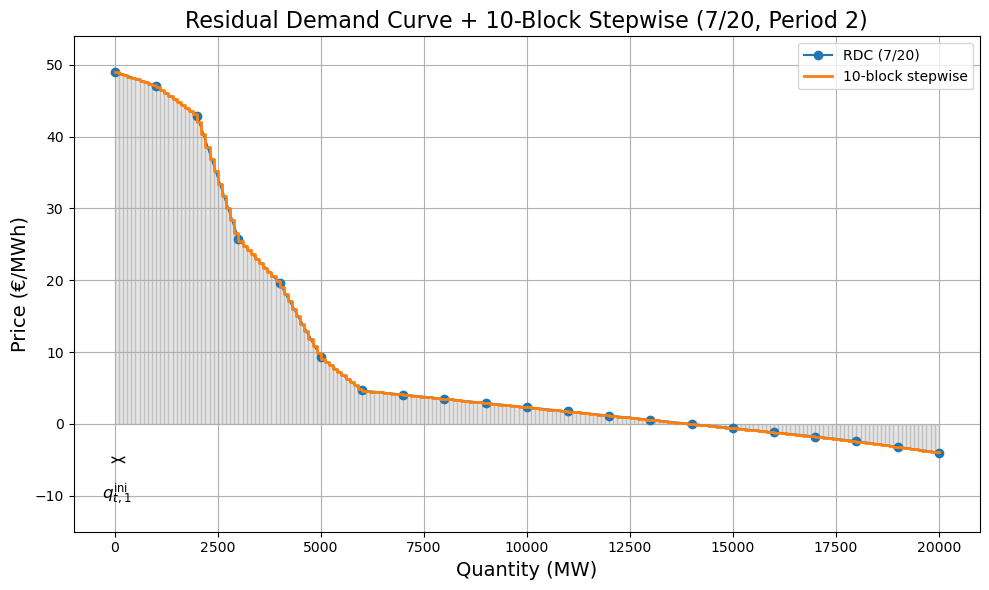

In [8]:


# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i],     price_grid[i+1]
            r0, r1 = resid[i],          resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- 1) 파라미터 설정 ---
period        = 2
date_str      = "20250720"         # 7월 20일
fn            = f"filteredcurve_{date_str}.csv"
B             = 200                 # 블록 수
wf_offer_grid = np.arange(0, 20001, 1000)

# --- 2) 데이터 읽기 & 전처리 ---
df = pd.read_csv(fn, encoding='utf-8-sig')
sub    = df[df['Time Period']==period]
supply = sub[sub['GC']=='V']
demand = sub[sub['GC']=='C']
if supply.empty or demand.empty:
    raise ValueError(f"{date_str}에 period={period} 데이터가 없습니다.")

# 공급/수요 누적 집계
s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
s_agg['CumulQty'] = s_agg['Amount'].cumsum()
d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

# 계단형 보간 함수
supply_func = interp1d(
    s_agg['Price'], s_agg['CumulQty'],
    kind='previous', bounds_error=False,
    fill_value=(0, s_agg['CumulQty'].iat[-1])
)
demand_func = interp1d(
    d_agg['Price'], d_agg['CumulQty'],
    kind='previous', bounds_error=False,
    fill_value=(d_agg['CumulQty'].iat[0], 0)
)

# 가격 그리드
price_grid  = np.linspace(
    min(s_agg['Price'].min(), d_agg['Price'].min()),
    max(s_agg['Price'].max(), d_agg['Price'].max()),
    500
)
supply_vals = supply_func(price_grid)
demand_vals = demand_func(price_grid)

# 잔여수요 계산
rdc_pts = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offer_grid)
if not rdc_pts:
    raise RuntimeError("RDC 점이 계산되지 않았습니다.")
q_vals, p_vals = zip(*rdc_pts)
qv = np.array(q_vals)
pv = np.array(p_vals)

# --- 3) Stepwise 근사 계산 ---
q_breaks = np.linspace(0, qv.max(), B+1)      # 블록 경계
block_prices = []
for b in range(B):
    mid_q = 0.5*(q_breaks[b] + q_breaks[b+1])
    # 중간점 가격을 원래 RDC에서 선형보간
    price_b = float(np.interp(mid_q, qv, pv))
    block_prices.append(price_b)
# 마지막 구간 닫기 위해 마지막 가격 추가
block_prices.append(block_prices[-1])

# --- 4) 시각화 ---
plt.figure(figsize=(10,6))

# 4.1) 원본 RDC
plt.plot(qv, pv, 'o-', label='RDC (7/20)', linewidth=1.5)

# 4.2) 계단식 stepwise
plt.step(q_breaks, block_prices, where='post',
         label='10-block stepwise', linewidth=2)

# 4.3) 각 블록 음영
for b in range(B):
    plt.fill_between(
        [q_breaks[b], q_breaks[b+1]],
        0, block_prices[b],
        color='grey', alpha=0.2
    )

# 4.4) 첫 블록(qᶦⁿⁱ) 길이 화살표
plt.annotate(
    '',
    xy=(q_breaks[1], -5), xytext=(q_breaks[0], -5),
    arrowprops=dict(arrowstyle='<->', color='black')
)
plt.text(
    0.5*(q_breaks[0]+q_breaks[1]), -8,
    r'$q^{\mathrm{ini}}_{t,1}$',
    ha='center', va='top', fontsize=12
)

# 4.5) 축·범례·제목
plt.xlabel('Quantity (MW)', fontsize=14)
plt.ylabel('Price (€/MWh)', fontsize=14)
plt.ylim(-15, max(pv.max(), block_prices[0]) * 1.1)
plt.title('Residual Demand Curve + 10-Block Stepwise (7/20, Period 2)', fontsize=16)
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


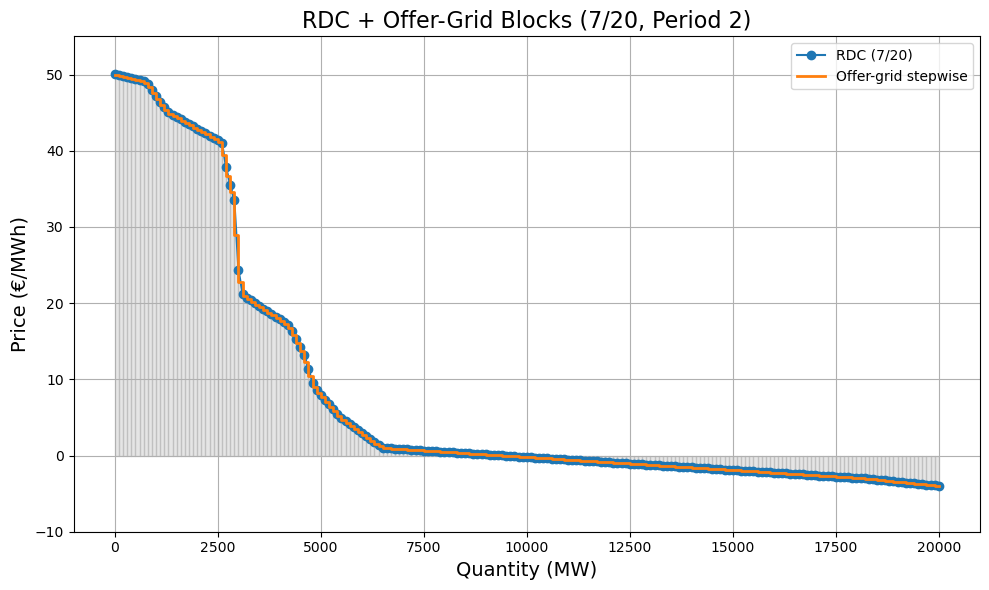

In [9]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d

# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i],     price_grid[i+1]
            r0, r1 = resid[i],          resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- 1) 파라미터 설정 ---
period        = 2
date_str      = "20250720"  
fn            = f"filteredcurve_{date_str}.csv"
df = pd.read_csv(fn, encoding='utf-8-sig')
wf_offer_grid = np.arange(0, 20001, 100)  # offer 기준 블록 경계

# --- 2) 데이터 읽기 & 전처리 ---
sub    = df[df['Time Period']==period]
supply = sub[sub['GC']=='V']
demand = sub[sub['GC']=='C']
if supply.empty or demand.empty:
    raise ValueError("데이터 부족")

# 공급/수요 누적곡선 만들기
s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
s_agg['CumulQty'] = s_agg['Amount'].cumsum()
d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

supply_func = interp1d(s_agg['Price'], s_agg['CumulQty'],
                       kind='previous', fill_value=(0, s_agg['CumulQty'].iat[-1]), bounds_error=False)
demand_func = interp1d(d_agg['Price'], d_agg['CumulQty'],
                       kind='previous', fill_value=(d_agg['CumulQty'].iat[0], 0), bounds_error=False)

price_grid  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
supply_vals = supply_func(price_grid)
demand_vals = demand_func(price_grid)

# RDC 점 계산
rdc_pts = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offer_grid)
qv, pv = zip(*rdc_pts)
qv = np.array(qv); pv = np.array(pv)

# --- 3) offer 그리드 기반 stepwise 계산 ---
# 각 offer 구간 중앙에서 가격 보간
offer_mids   = (wf_offer_grid[:-1] + wf_offer_grid[1:]) / 2
block_prices = np.interp(offer_mids, qv, pv)
# 마지막 구간 닫기
block_prices = np.append(block_prices, block_prices[-1])

# --- 4) 시각화 ---
plt.figure(figsize=(10,6))

# 원본 RDC
plt.plot(qv, pv, 'o-', label='RDC (7/20)', linewidth=1.5)

# offer-grid 기반 계단식 근사
plt.step(wf_offer_grid, block_prices, where='post',
         label='Offer-grid stepwise', linewidth=2)

# 각 offer 블록 음영
for i in range(len(wf_offer_grid)-1):
    plt.fill_between(
        [wf_offer_grid[i], wf_offer_grid[i+1]],
        0, block_prices[i],
        color='grey', alpha=0.2
    )

# 축·제목·범례
plt.xlabel('Quantity (MW)', fontsize=14)
plt.ylabel('Price (€/MWh)', fontsize=14)
plt.title('RDC + Offer-Grid Blocks (7/20, Period 2)', fontsize=16)
plt.ylim(-10, max(pv.max(), block_prices.max())*1.1)
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


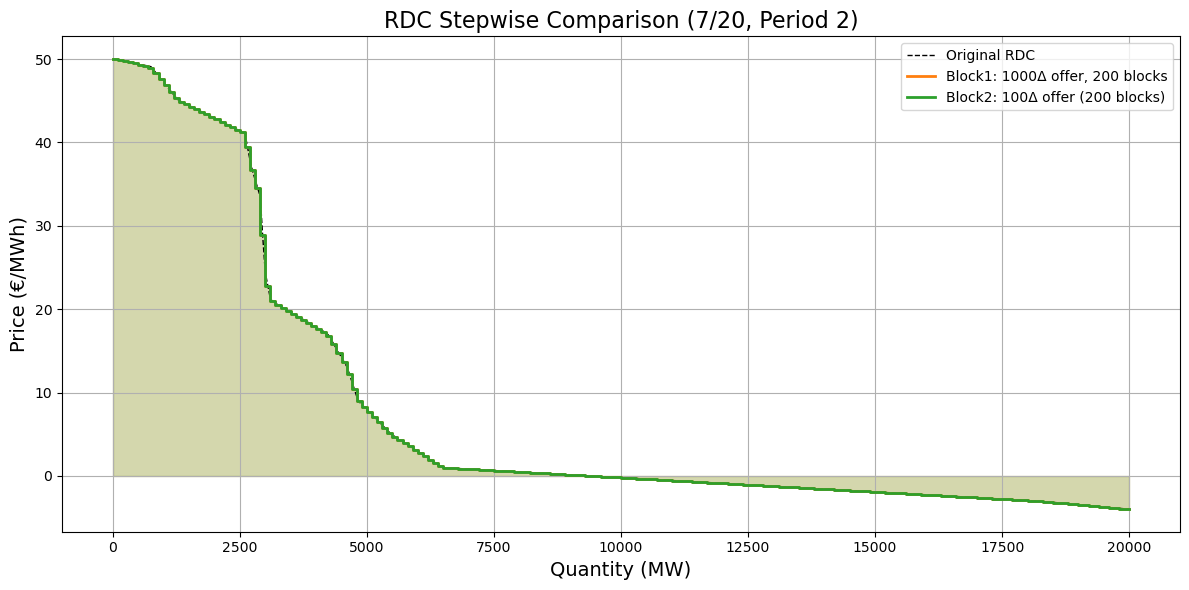

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i], price_grid[i+1]
            r0, r1 = resid[i], resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- 1) 파라미터 설정 ---
period     = 2

date_str      = "20250720"  
fn            = f"filteredcurve_{date_str}.csv"
df = pd.read_csv(fn, encoding='utf-8-sig')
# (1) grid1: wf offers 0,1000,...20000
grid1 = np.arange(0, 20001, 100)
# (2) grid2: wf offers 0,100,200,...20000
grid2 = np.arange(0, 20001, 100)

# 균등분할 블록 개수 (block1 uses grid1 rdc)
B_blocks = 200

# --- 2) 데이터 읽기 & 누적곡선 생성 ---
sub    = df[df['Time Period'] == period]
supply = sub[sub['GC'] == 'V']
demand = sub[sub['GC'] == 'C']

s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
s_agg['CumulQty'] = s_agg['Amount'].cumsum()
d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

supply_fn = interp1d(s_agg['Price'], s_agg['CumulQty'], kind='previous',
                     fill_value=(0, s_agg['CumulQty'].iat[-1]), bounds_error=False)
demand_fn = interp1d(d_agg['Price'], d_agg['CumulQty'], kind='previous',
                     fill_value=(d_agg['CumulQty'].iat[0], 0), bounds_error=False)

price_grid  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
supply_vals = supply_fn(price_grid)
demand_vals = demand_fn(price_grid)

# --- 3) RDC 계산 on both grids ---
rdc1 = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, grid1)
rdc2 = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, grid2)

q1, p1 = map(np.array, zip(*rdc1))
q2, p2 = map(np.array, zip(*rdc2))

# --- 4) stepwise 근사 계산 ---
# 4.1 블록1: 균등분할 B_blocks based on q1.max()
q_breaks1 = np.linspace(0, q1.max(), B_blocks + 1)
prices1   = [float(np.interp((q_breaks1[b] + q_breaks1[b+1]) / 2, q1, p1))
             for b in range(B_blocks)]
prices1.append(prices1[-1])

# 4.2 블록2: grid2 based
mids2     = (grid2[:-1] + grid2[1:]) / 2
prices2   = list(np.interp(mids2, q2, p2)) + [np.interp(mids2[-1], q2, p2)]

# --- 5) 시각화 ---
plt.figure(figsize=(12,6))

# 원본 RDC (for reference, using dense grid)
dense_offers = np.arange(0, 20001, 50)
dense_rdc    = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, dense_offers)
qd, pd      = map(np.array, zip(*dense_rdc))
plt.plot(qd, pd, 'k--', linewidth=1, label='Original RDC')

# 첫 번째: grid1=1000 & B_blocks=200
plt.step(q_breaks1, prices1, where='post', color='C1', linewidth=2,
         label='Block1: 1000Δ offer, 200 blocks')
plt.fill_between(q_breaks1, 0, prices1, step='post', color='C1', alpha=0.2)

# 두 번째: grid2=100Δ offer, 200 blocks
plt.step(grid2, prices2, where='post', color='C2', linewidth=2,
         label='Block2: 100Δ offer (200 blocks)')
plt.fill_between(grid2, 0, prices2, step='post', color='C2', alpha=0.2)

# 꾸미기
plt.xlabel('Quantity (MW)', fontsize=14)
plt.ylabel('Price (€/MWh)', fontsize=14)
plt.title('RDC Stepwise Comparison (7/20, Period 2)', fontsize=16)
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


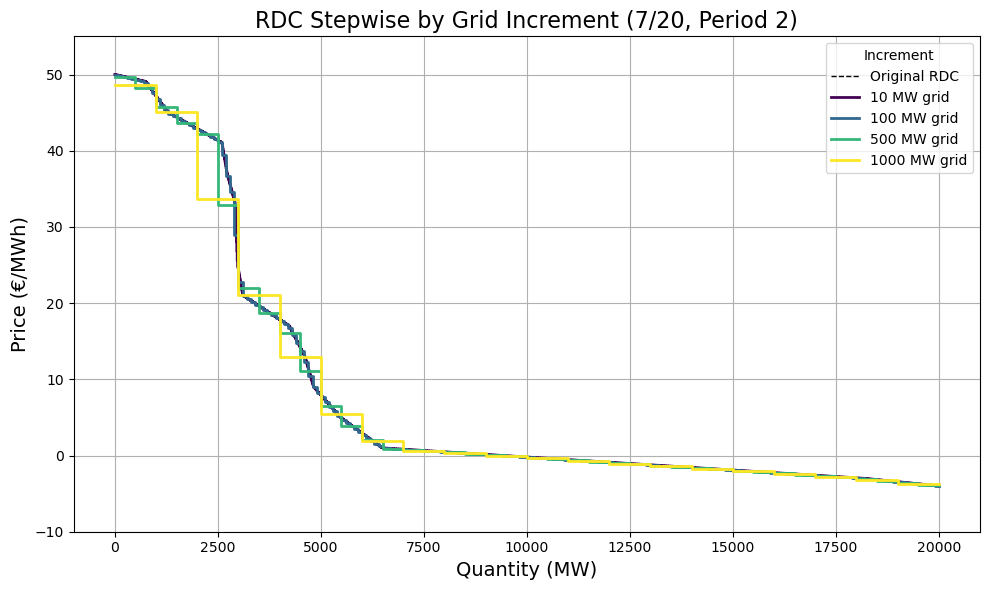

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i], price_grid[i+1]
            r0, r1 = resid[i], resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- 1) 파라미터 설정 ---
period    = 2
date_str  = "20250720"
csv_file  = f"filteredcurve_{date_str}.csv"

# --- 2) 데이터 읽기 & 누적곡선 생성 ---
df    = pd.read_csv(csv_file, encoding='utf-8-sig')
sub   = df[df['Time Period'] == period]
supply = sub[sub['GC'] == 'V']
demand = sub[sub['GC'] == 'C']

s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
s_agg['CumulQty'] = s_agg['Amount'].cumsum()
d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

supply_fn = interp1d(s_agg['Price'], s_agg['CumulQty'], kind='previous',
                     fill_value=(0, s_agg['CumulQty'].iat[-1]), bounds_error=False)
demand_fn = interp1d(d_agg['Price'], d_agg['CumulQty'], kind='previous',
                     fill_value=(d_agg['CumulQty'].iat[0], 0), bounds_error=False)

price_grid  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
supply_vals = supply_fn(price_grid)
demand_vals = demand_fn(price_grid)

# 원본 RDC
dense_offers = np.arange(0, 20001, 1)
rdc_dense    = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, dense_offers)
qd, pd       = map(np.array, zip(*rdc_dense))

# 비교할 step sizes
step_sizes = [10, 100, 500, 1000]
colors     = plt.cm.viridis(np.linspace(0,1,len(step_sizes)))

# --- 3) 시각화 ---
plt.figure(figsize=(10,6))
plt.plot(qd, pd, 'k--', label='Original RDC', linewidth=1)

for step, color in zip(step_sizes, colors):
    grid = np.arange(0, 20001, step)
    rdc_pts = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, grid)
    qg, pg  = map(np.array, zip(*rdc_pts))
    mids    = 0.5 * (grid[:-1] + grid[1:])
    bp      = np.interp(mids, qg, pg)
    bp      = np.append(bp, bp[-1])
    plt.step(grid, bp, where='post', color=color, linewidth=2, label=f'{step} MW grid')

plt.xlabel('Quantity (MW)', fontsize=14)
plt.ylabel('Price (€/MWh)', fontsize=14)
plt.title('RDC Stepwise by Grid Increment (7/20, Period 2)', fontsize=16)
plt.ylim(-10, pd.max()*1.1)
plt.legend(title='Increment', loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


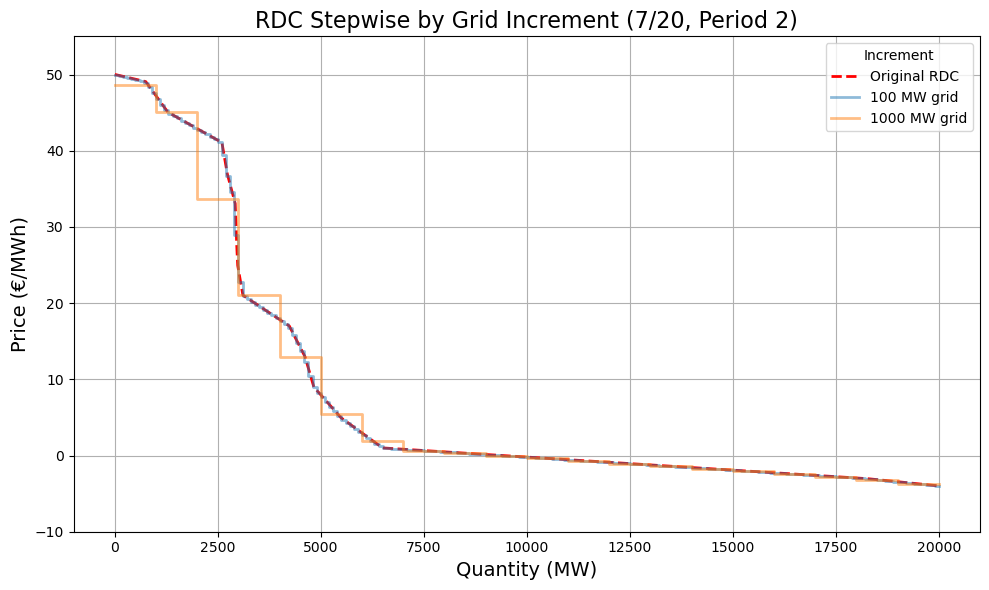

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i], price_grid[i+1]
            r0, r1 = resid[i], resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- 1) 파라미터 설정 ---
period    = 2
date_str  = "20250720"
csv_file  = f"filteredcurve_{date_str}.csv"

# --- 2) 데이터 읽기 & 누적곡선 생성 ---
df     = pd.read_csv(csv_file, encoding='utf-8-sig')
sub    = df[df['Time Period'] == period]
supply = sub[sub['GC'] == 'V']
demand = sub[sub['GC'] == 'C']

s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
s_agg['CumulQty'] = s_agg['Amount'].cumsum()
d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

supply_fn = interp1d(
    s_agg['Price'], s_agg['CumulQty'], kind='previous',
    fill_value=(0, s_agg['CumulQty'].iat[-1]), bounds_error=False
)
demand_fn = interp1d(
    d_agg['Price'], d_agg['CumulQty'], kind='previous',
    fill_value=(d_agg['CumulQty'].iat[0], 0), bounds_error=False
)

price_grid  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
supply_vals = supply_fn(price_grid)
demand_vals = demand_fn(price_grid)

# 원본 RDC (초밀집 offer grid)
dense_offers = np.arange(0, 20001, 1)
qd, pd = map(np.array, zip(*compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, dense_offers)))

# 비교할 step sizes
step_sizes = [100,  1000]
colors     = plt.cm.tab10(np.arange(len(step_sizes)))  # 서로 다른 컬러

# --- 3) 시각화 ---
plt.figure(figsize=(10,6))

# 원본 RDC: 빨간 점선
plt.plot(qd, pd,
         color='red',
         linestyle='--',
         linewidth=2,
         label='Original RDC')

# stepwise: 각기 다른 색 + 투명도
for step, color in zip(step_sizes, colors):
    grid    = np.arange(0, 20001, step)
    pts     = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, grid)
    qg, pg  = map(np.array, zip(*pts))
    mids    = 0.5 * (grid[:-1] + grid[1:])
    bp      = np.interp(mids, qg, pg)
    bp      = np.append(bp, bp[-1])

    plt.step(grid, bp,
             where='post',
             color=color,
             alpha=0.5,
             linewidth=2,
             label=f'{step} MW grid')

plt.xlabel('Quantity (MW)', fontsize=14)
plt.ylabel('Price (€/MWh)', fontsize=14)
plt.title('RDC Stepwise by Grid Increment (7/20, Period 2)', fontsize=16)
plt.ylim(-10, pd.max() * 1.1)
plt.legend(title='Increment', loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\symply_jina\AppData\Local\Temp\ipykernel_5648\3123050770.py:91: RuntimeWarning: invalid value encountered in divide
  slopes = np.abs(np.diff(pv) / np.diff(qv))
C:\Users\symply_jina\AppData\Local\Temp\ipykernel_5648\3123050770.py:91: RuntimeWarning: invalid value encountered in divide
  slopes = np.abs(np.diff(pv) / np.diff(qv))
C:\Users\symply_jina\AppData\Local\Temp\ipykernel_5648\3123050770.py:91: RuntimeWarning: invalid value encountered in divide
  slopes = np.abs(np.diff(pv) / np.diff(qv))
C:\Users\symply_jina\AppData\Local\Temp\ipykernel_5648\3123050770.py:91: RuntimeWarning: invalid value encountered in divide
  slopes = np.abs(np.diff(pv) / np.diff(qv))
C:\Users\symply_jina\AppData\Local\Temp\ipykernel_5648\3123050770.py:91: RuntimeWarning: invalid value encountered in divide
  slopes = np.abs(np.diff(pv) / np.diff(qv))
C:\Users\symply_jina\AppData\Local\Temp\ipykernel_5648\3123050770.py:91: RuntimeWarning: invalid value encountered in divide
  slopes = np.abs(np.diff

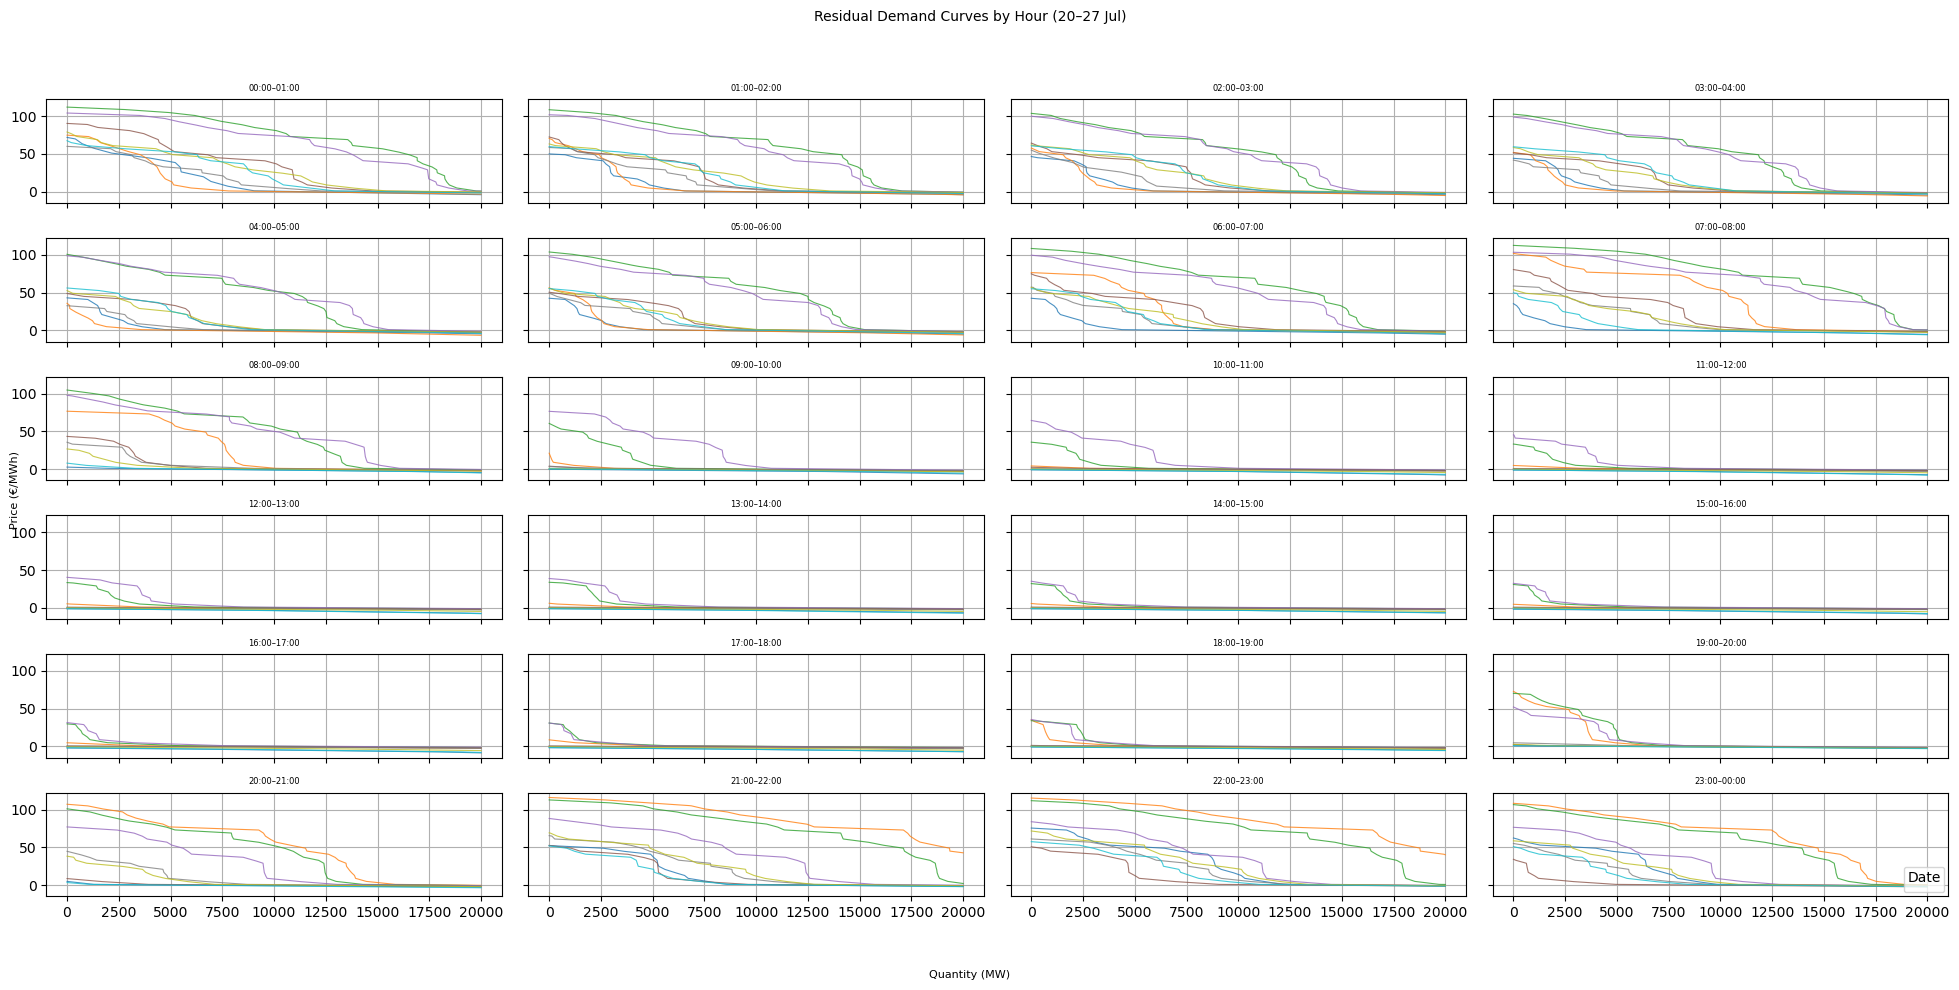

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

# --- A) RDC 계산 함수 (생략 없이 포함) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i], price_grid[i+1]
            r0, r1 = resid[i], resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- B) 공통 설정 ---
days          = range(20,28)                 # 7/20~7/27
colors        = plt.cm.tab10(np.linspace(0,1,len(days)))
B             = 1000                        # (기존 uniform용, adaptive에선 사용 안 함)
qini            = {}
qmax            = {}
lambda_da_block = {}
orig_cp         = {}

# --- C) 4×6 서브플롯 생성 (figsize 20×10) ---
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
                         sharex=True, sharey=True)
axes = axes.flatten()

# --- D) 각 Period(1~24) 에 대해 ---
for period in range(1,25):
    ax = axes[period-1]
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')``
        except FileNotFoundError:
            continue

        sub = df[df['Time Period']==period]
        sup = sub[sub['GC']=='V']
        dem = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 공급/수요 누적 집계
        s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()
        d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 계단 보간 함수
        s_f = interp1d(
            s_agg['Price'], s_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(0, s_agg['Cumul'].iat[-1])
        )
        d_f = interp1d(
            d_agg['Price'], d_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(d_agg['Cumul'].iat[0], 0)
        )

        # 가격 격자
        pg = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
        sv = s_f(pg)
        dv = d_f(pg)

        # 원래 청산가격
        def resid0(p):
            return d_f(p) - s_f(p)
        sol0 = root_scalar(resid0, bracket=[pg[0], pg[-1]], method='bisect')
        orig_cp[(date_str, period)] = sol0.root if sol0.converged else np.nan

        # Residual Demand Curve 점 추출
        wf_offer_grid = np.arange(0, 20000, 1)
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)
        qv = np.array(qv)
        pv = np.array(pv)

        # ——— [NEW] Adaptive stepwise 근사 파라미터 계산 —————————
        slopes = np.abs(np.diff(pv) / np.diff(qv))
        # 기울기 분포의 70%, 30% percentile을 기준으로 steep/medium/flat 구분
        alpha, beta = np.percentile(slopes, [70, 30])
        block_sizes = [10 if s > alpha else 50 if s > beta else 200 for s in slopes]

        # adaptive q_breaks 생성
        q_breaks = [0]
        current_q = 0
        i = 0
        while current_q < qv.max():
            step_size = block_sizes[min(i, len(block_sizes)-1)]
            current_q += step_size
            q_breaks.append(min(current_q, qv.max()))
            i += 1
        q_breaks = np.unique(q_breaks)
        delta_qs = np.diff(q_breaks)

        # 파라미터 저장
        for b in range(len(delta_qs)):
            mid = 0.5 * (q_breaks[b] + q_breaks[b+1])
            qini   [(date_str, period, b)] = float(q_breaks[b])
            qmax   [(date_str, period, b)] = float(delta_qs[b])
            lambda_da_block[(date_str, period, b)] = float(np.interp(mid, qv, pv))
        # ————————————————————————————————

        # RDC Curve만 플롯
        ax.plot(qv, pv,
                '-',                # 실선
                color=color,
                linewidth=0.8,
                alpha=0.8)

    # subplot 제목
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    ax.set_title(f"{hh1}–{hh2}", fontsize=6)
    ax.grid(True)

# --- E) 공통 레이블 & 레이아웃 ---
fig.supxlabel('Quantity (MW)', fontsize=8)
fig.supylabel('Price (€/MWh)', fontsize=8)
fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=10)
axes[-1].legend(title='Date', fontsize=6, loc='lower right')
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()
